## Develop the concatenation of individual runs (for instance for cumulative time series)

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


## Settings

In [2]:
varias = ['fgco2','nbp']
models = ['IPSL-CM6-ESMCO2','GFDL-ESM2M','NorESM2-LM','GISSE2.1-G-CC2','UKESM1-2','EC-Earth3-ESM-1']#[]#,
runs = pruns.get_run_list('tipmip_tier1')#[1:]
ref_year = 1

model_dict = pmods.get_model_dict('all')
run_dict = pruns.get_run_dict()
root_dir = f'./../01_postprocessed_data/global_time_series'
rolling_mean_years = 31


## Defining some functions

In [3]:
def get_freq_input(model):
    if model == 'GISSE2.1-G-CC2':
        freq_input = 'yearly'
    else:
        freq_input = 'monthly'
    return freq_input

def get_stat(varia,default=True):
    if default == True:
        if varia in ['tas','tos']:
            stat = 'mean'
        elif varia in ['fgco2','intpp','nbp','npp']:
            stat = 'integral'
    else:
        stat = 'mean'
    return stat

def convert_units(varia,stat,da):
    if varia == 'fgco2' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2 x s','kgC/m2/s x m2 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'nbp' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2 x s','kgC/m2/s x m2 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'intpp' and stat == 'integral' and da.units in ['mol m-2 s-1 x m2 x s','mol/m2/s x m2 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'npp' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2 x s','kg/m2/s x m2 x s']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    else:
        da_conv = da
    return da_conv

def trim_for_plotting(da, rc, run, ref_year, model_dict):
    
    model = rc.model
    varia = rc.varia
    freq = rc.freq
    stat = rc.stat

    if run in ["esm-up2p0"]:
        run_names, run_years = rc.get_run_history_years("esm-up2p0-gwl4p0")

        trim_year = run_years[-1][0]
        trim_year_shifted = trim_year - model_dict[model].rampup_start_year + ref_year

        da_trimmed = da.sel(
            time=slice(f"{ref_year:04d}-01-01", f"{trim_year_shifted:04d}-01-01")
        )

    elif run in ["esm-up2p0-gwl2p0", "esm-up2p0-gwl4p0"]:
        run_names, run_years = rc.get_run_history_years(run)

        trim_year = run_years[-1][0] + 50
        trim_year_shifted = trim_year - model_dict[model].rampup_start_year + ref_year

        da_trimmed = da.sel(
            time=slice(f"{ref_year:04d}-01-01", f"{trim_year_shifted:04d}-01-01")
        )

    else:
        da_trimmed = da

    return da_trimmed


## Compute and plot annual means against time

Cannot do anything for fgco2, GISSE2.1-G-CC2, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0.


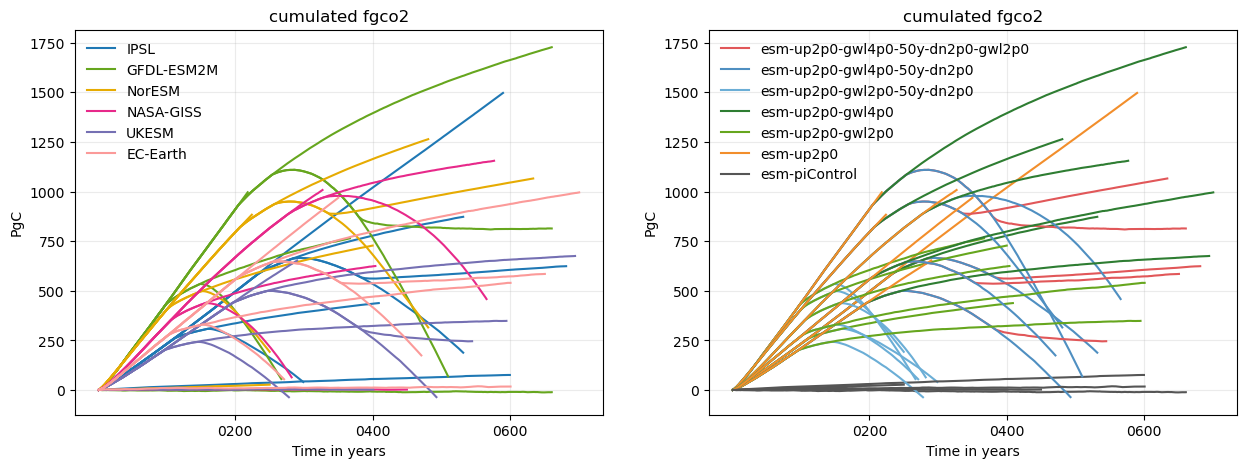

Cannot do anything for nbp, GISSE2.1-G-CC2, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0.


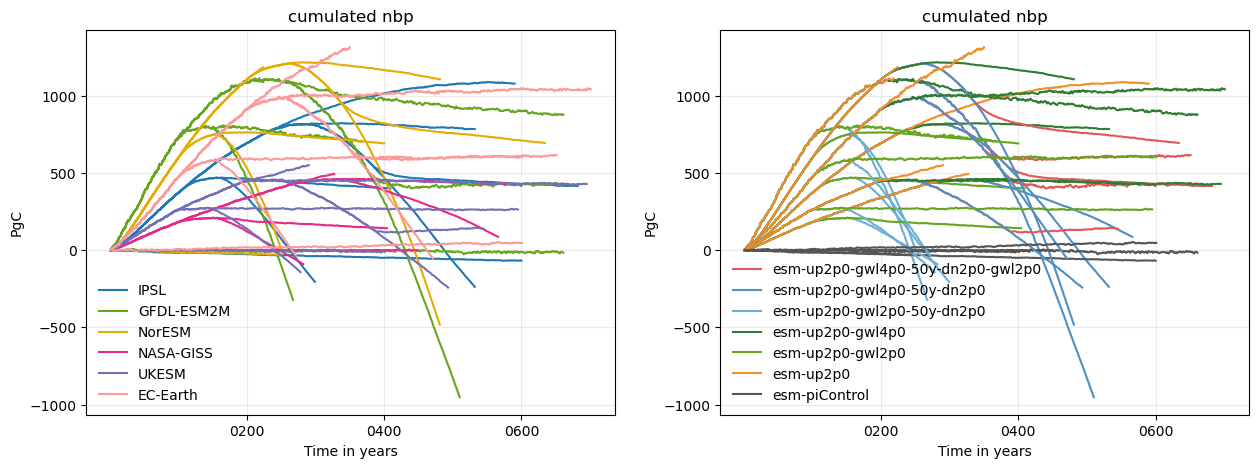

In [6]:
for varia in varias:
    stat = get_stat(varia)
    fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

    for mdx, model in enumerate(models):
        freq = get_freq_input(model)
        mgrab = MODELgrabber.get_grabber(model)
        member = mgrab.get_member()

        rc = RConcatenator(
            model=model,
            member=member,
            varia=varia,
            freq=freq,
            stat=stat,
            root_dir=root_dir,
        )

        for rdx, run in enumerate(runs[::-1]):

            file_string = f'{root_dir}/{varia}/{model}/{run}/{member}/{freq}/global_{stat}/{varia}_{model}_{run}_{member}_global_{stat}.nc'

            if miniFuncs.is_available(file_string):

                da = rc.get_concatenated_da(run=run, ref_year=ref_year)

                # annual means
                da = da.resample(time='1YS').mean(dim='time')

                # integrate
                if da.size > 0:
                    da_int = TimeOperator.integrate_in_time(da)
                    da_int = convert_units(varia, stat, da_int)

                    # labels
                    mlab = model_dict[model].plotting_name if run == 'esm-up2p0' else ''
                    rlab = run if mdx == 0 else ''

                    ax[0].plot(da_int.time, da_int, color=model_dict[model].color_id, label=mlab)
                    ax[1].plot(da_int.time, da_int, color=run_dict[run].color_id, label=rlab)
            else:
                print(f'Cannot do anything for {varia}, {model}, {run}.')

    # --- finalize plot ---
    for axi in ax:
        axi.grid(alpha=0.25)
        axi.legend(frameon=False)
        axi.set_title(f"cumulated {varia}")

        if "da_int" in locals():
            axi.set_ylabel(da_int.attrs.get("units", ""))

        if "da_ref" in locals():
            axi.set_xlabel(f"Time in years")

    plt.show()

## Compute and plot annual means against delta tas (smoothed)

Failed for fgco2, GISSE2.1-G-CC2, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0: Missing run history for fgco2, GISSE2.1-G-CC2, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0


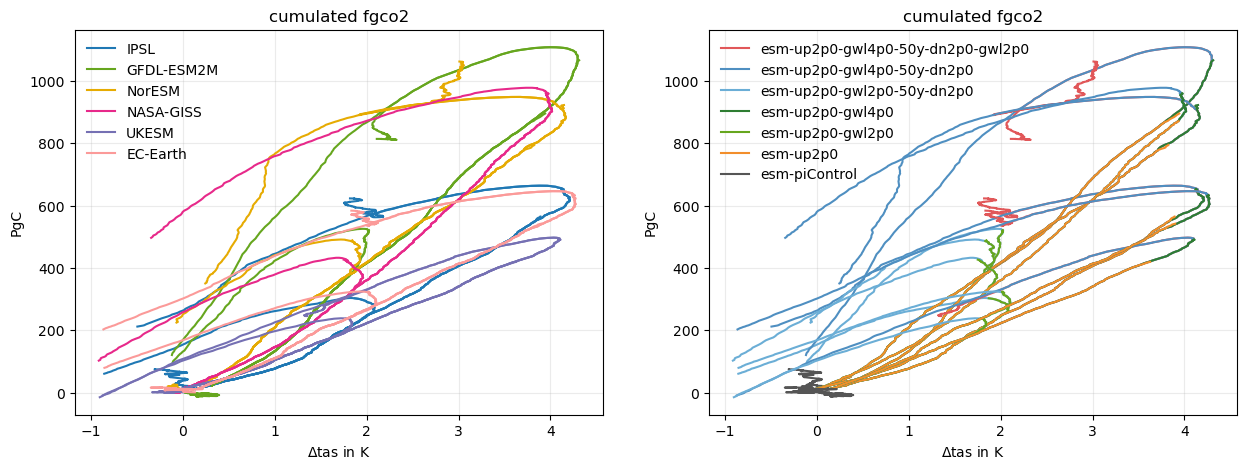

Failed for nbp, GISSE2.1-G-CC2, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0: Missing run history for nbp, GISSE2.1-G-CC2, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0


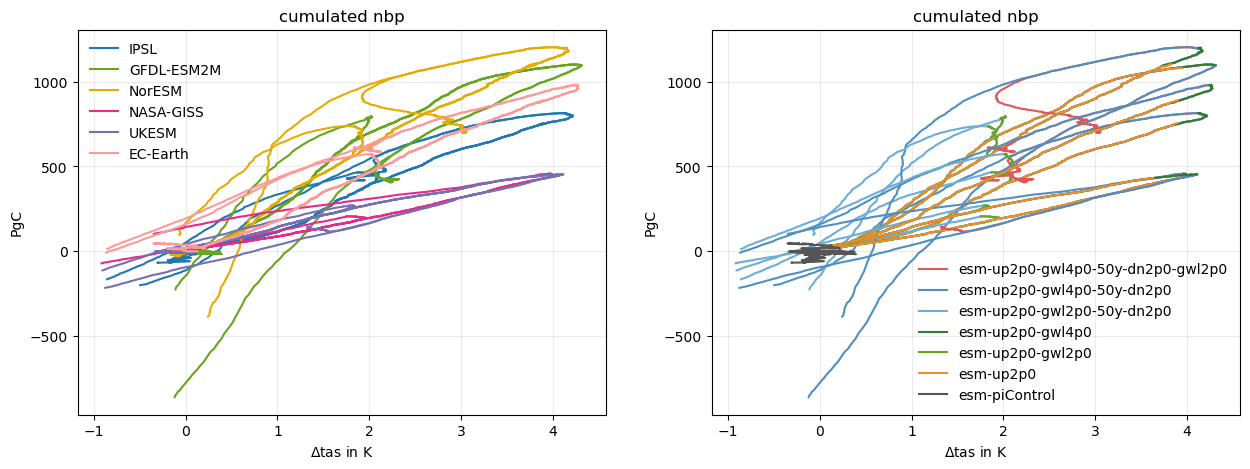

In [5]:
for varia in varias:
    stat = get_stat(varia)
    fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

    for mdx, model in enumerate(models):
        freq = get_freq_input(model)
        mgrab = MODELgrabber.get_grabber(model)
        member = mgrab.get_member()

        rc = RConcatenator(
            model=model,
            member=member,
            varia=varia,
            freq=freq,
            stat=stat,
            root_dir=root_dir,
        )

        rc_tas = RConcatenator(
            model=model,
            member=member,
            varia="tas",
            freq=freq,
            stat="mean",
            root_dir=root_dir,
        )

        try:
            ref_dataset = rc_tas.get_concatenated_da(run="esm-piControl", ref_year=ref_year)

            ref_value = (ref_dataset.sel(time=slice(f"{ref_year:04d}-01-01", f"{ref_year:04d}-12-31")).mean(dim="time").values)
        except Exception:
            print(f"Reference failed for {model}")
            continue

        for rdx, run in enumerate(runs[::-1]):

            try:
                # --- main variable ---
                da = rc.get_concatenated_da(run=run, ref_year=ref_year)
                da = da.resample(time="1YS").mean()

                # --- reference tas anomaly ---
                with xr.set_options(keep_attrs=True):
                    da_ref = rc_tas.get_concatenated_da(run=run, ref_year=ref_year) - ref_value
                    da_ref = da_ref.resample(time="1YS").mean()

                # --- trim ---
                da = trim_for_plotting(da, rc, run, ref_year, model_dict)
                da_ref = trim_for_plotting(da_ref, rc_tas, run, ref_year, model_dict)

                # skip empty
                if da.size == 0 or da_ref.size == 0:
                    continue

                # --- integrate ---
                da_int = TimeOperator.integrate_in_time(da)
                da_int = convert_units(varia, stat, da_int)

                # --- smooth ---
                da_int = da_int.rolling(time=rolling_mean_years, center=True, min_periods=1).mean()

                da_ref = da_ref.rolling(time=rolling_mean_years, center=True, min_periods=1).mean()

                # --- labels ---
                mlab = model_dict[model].plotting_name if run == "esm-up2p0" else ""
                rlab = run if mdx == 0 else ""

                # --- plot ---
                ax[0].plot(da_ref, da_int, color=model_dict[model].color_id, label=mlab)
                ax[1].plot(da_ref, da_int, color=run_dict[run].color_id, label=rlab)

            except Exception as e:
                print(f"Failed for {varia}, {model}, {run}: {e}")
                continue

    # --- finalize plot ---
    for axi in ax:
        axi.grid(alpha=0.25)
        axi.legend(frameon=False)
        axi.set_title(f"cumulated {varia}")

        if "da_int" in locals():
            axi.set_ylabel(da_int.attrs.get("units", ""))

        if "da_ref" in locals():
            axi.set_xlabel(f"$\\Delta$tas in {da_ref.attrs.get('units', '')}")

    plt.show()